# Histogramas (y conceptos asociados)

Los histogramas sirven para mostrar la dispersión de datos sueltos sin un "orden" (temporal o secuencial) o dependencia con otro dato.

**Construcción de un histograma**
1. Dividir el espacio de valores posibles en intervalos consecutivos y de igual tamaño
2. Contar cuantos datos caen en cada intervalo
3. Relizar un gráfico de barras con el correspondiente conteo



## Ejemplo de datos e histograma


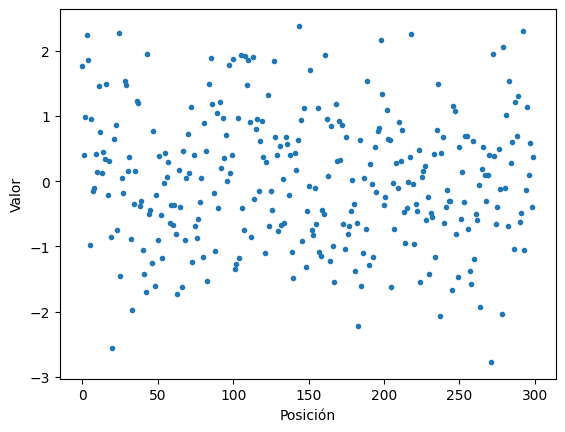

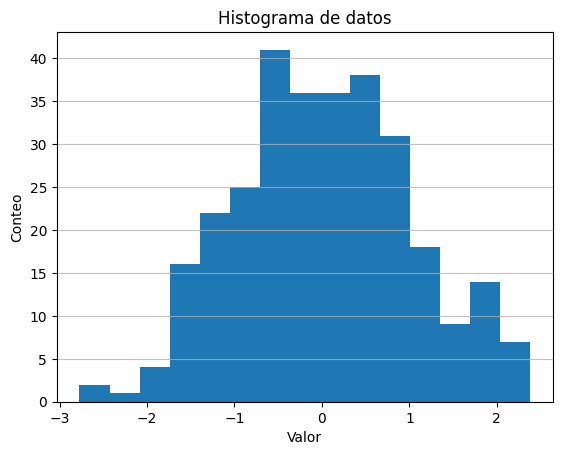

In [33]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
# Generar 300 datos aleatorios con distribución normal
# np.random.randn(300) genera 300 números de una distribución normal estándar (media=0, desviación estándar=1)
datos1 = np.random.randn(300)
datos2 = np.random.randn(300)*0.3+1.5

# Mostrar los primeros 10 datos generados para verificar
plt.figure()
plt.plot(datos1,'.')
plt.ylabel('Valor')
plt.xlabel('Posición')
plt.show()

# Crear el histograma
plt.figure()
plt.hist(datos1, 15)
# plt.hist(data, bins=15, edgecolor='black')
plt.title('Histograma de datos')
plt.xlabel('Valor')
plt.ylabel('Conteo')
plt.grid(axis='y', alpha=0.75)
plt.show()


## Ejemplo conceptual


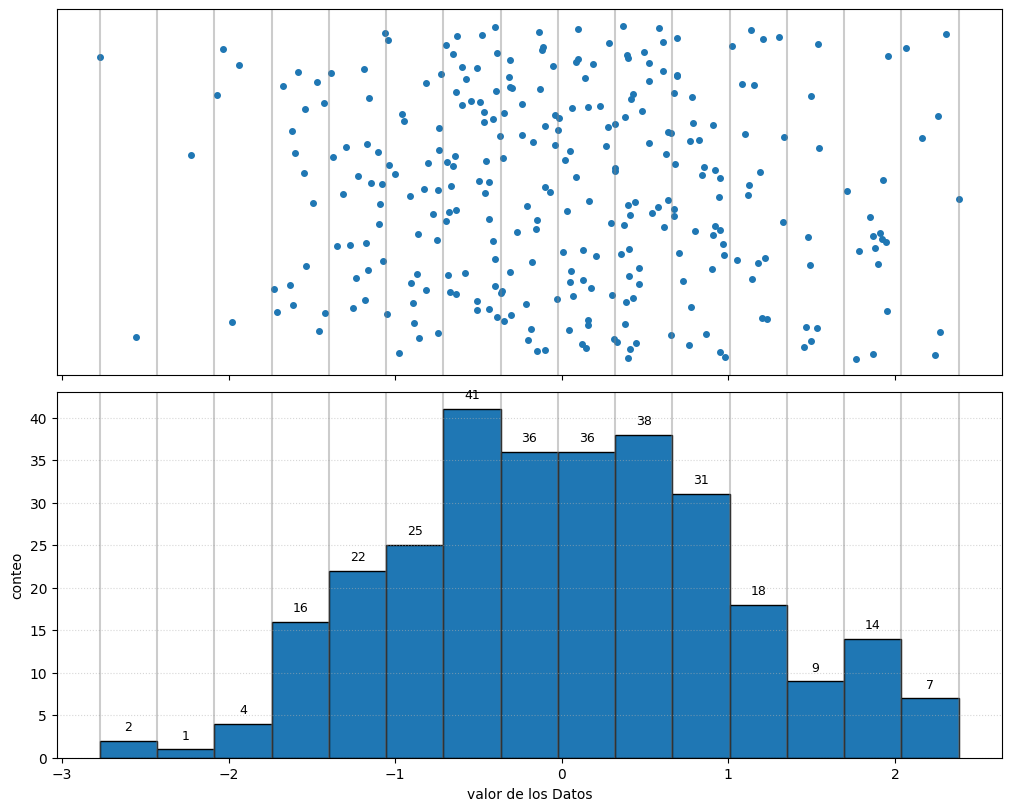

In [34]:
# 1. Calcular los 'bins' del histograma. Usamos 15 bins como en el ejemplo anterior.
num_bins = 15
hist_counts, hist_bins = np.histogram(datos1, bins=num_bins)

# 2. Crear una figura y dos subgráficos (ax0 arriba, ax1 abajo) compartiendo el eje x.
fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 8), constrained_layout=True)

# --- Subgráfico Superior: Puntos de datos individuales
# Se grafican los puntos de 'data' en el eje x, el eje y es la posición del dato

ax0.plot(datos1,np.arange(len(datos1)), '.',  markersize=8)
# ax0.set_ylabel('posición')
ax0.set_yticks([]) # Ocultar los 'ticks' del eje y ya que es arbitrario para este tipo de gráfico

# Añadir líneas de rejilla verticales alineadas con los límites de los 'bins' del histograma.
for ax in (ax0,ax1):
  for bin_edge in hist_bins:
    ax.axvline(bin_edge, color='gray', linestyle='-', alpha=0.4)

# --- Subgráfico Inferior: Histograma ---
ax1.hist(datos1, bins=hist_bins, edgecolor='black')
# ax1.set_title('Histograma de Datos')
ax1.set_xlabel('valor de los Datos')
ax1.set_ylabel('conteo')
ax1.grid(axis='y', alpha=0.5, ls=":")

# Añadir el valor del conteo sobre cada bin
for count, bin_edge_start, bin_edge_end in zip(hist_counts, hist_bins[:-1], hist_bins[1:]):
    if count > 0: # Solo agregar texto si hay conteo en el bin
        x_center = (bin_edge_start + bin_edge_end) / 2
        y_position = count + (ax1.get_ylim()[1] * 0.02) # Un pequeño desplazamiento hacia arriba
        ax1.text(x_center, y_position, str(int(count)), ha='center', va='bottom', fontsize=9, color='black')

plt.show()

## Animación


In [96]:
from IPython.display import Image, display

# display(Image(filename=animation_filename))
display(Image(url="https://marceluda.github.io/python-para-fisicos/tuto/labo2/06_graficos_avanzandos/animation_histograma.gif", width=700))

### Codigo de animación

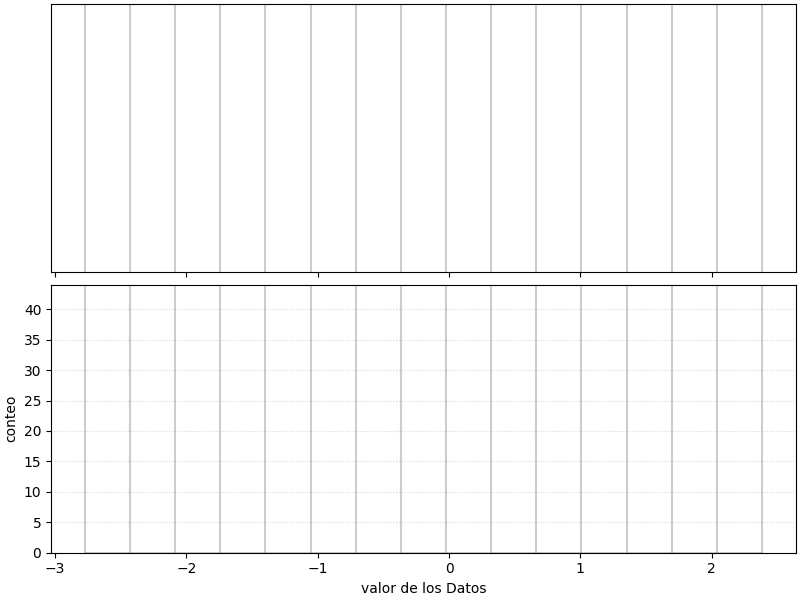

In [56]:
!gdown 1okTeQ8N0r974_NU7Bx_CMD3jiI9SxtWt
animation_filename = "animation.gif"

from matplotlib.animation import FuncAnimation, PillowWriter
import os

num_bins = 15
hist_counts, hist_bins = np.histogram(datos1, bins=num_bins)


def update(n):
    ax0.clear()
    ax1.clear()
    ax0.plot(datos1[:n],np.arange(len(datos1[:n])), '.',  markersize=8)
    # ax0.set_ylabel('posición')
    ax0.set_yticks([]) # Ocultar los 'ticks' del eje y ya que es arbitrario para este tipo de gráfico

    # Añadir líneas de rejilla verticales alineadas con los límites de los 'bins' del histograma.
    for ax in (ax0,ax1):
      for bin_edge in hist_bins:
        ax.axvline(bin_edge, color='gray', linestyle='-', alpha=0.4)

    # --- Subgráfico Inferior: Histograma ---
    hist_counts2, hist_bins2, _ = ax1.hist(datos1[:n], bins=hist_bins, edgecolor='black')
    # ax1.set_title('Histograma de Datos')
    ax1.set_xlabel('valor de los Datos')
    ax1.set_ylabel('conteo')
    ax1.grid(axis='y', alpha=0.5, ls=":")

    # Añadir el valor del conteo sobre cada bin
    for count, bin_edge_start, bin_edge_end in zip(hist_counts2, hist_bins2[:-1], hist_bins2[1:]):
        if count > 0: # Solo agregar texto si hay conteo en el bin
            x_center = (bin_edge_start + bin_edge_end) / 2
            y_position = count + (ax1.get_ylim()[1] * 0.02) # Un pequeño desplazamiento hacia arriba
            ax1.text(x_center, y_position, str(int(count)), ha='center', va='bottom', fontsize=9, color='black')

    ax0.set_ylim(-15,314)
    ax1.set_ylim(0,44)


# Check if the GIF file already exists
if not os.path.exists(animation_filename):
    fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), constrained_layout=True)

    ani = FuncAnimation(fig, update, frames=np.arange(300))

    # Save as GIF using PillowWriter
    writer = PillowWriter(fps=15)
    ani.save(animation_filename, writer=writer)
    print(f"Animation saved as {animation_filename}")







---


## Variaciones de formato


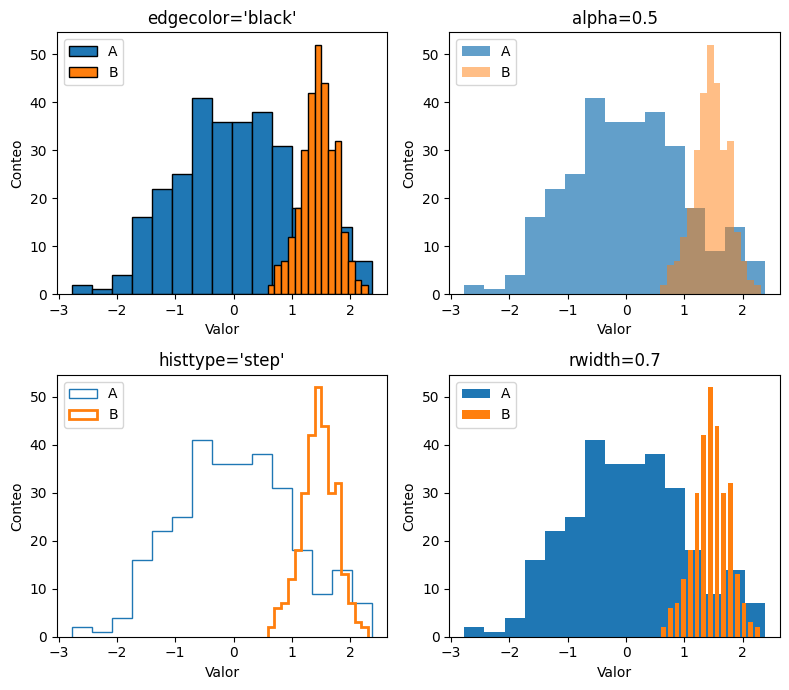

In [59]:
# Creamos la figura
plt.figure(figsize=(8,7))

# Subfigura 1
plt.subplot(2,2,1)
plt.hist(datos1,15, edgecolor='black', label='A')
plt.hist(datos2,15, edgecolor='black', label='B')
plt.ylabel('Conteo')
plt.xlabel('Valor')
plt.title("edgecolor='black'")
plt.legend()

# Subfigura 2
plt.subplot(2,2,2)
plt.hist(datos1,15, alpha=0.7, label='A')
plt.hist(datos2,15, alpha=0.5, label='B')
plt.ylabel('Conteo')
plt.xlabel('Valor')
plt.title("alpha=0.5")
plt.legend()

# Subfigura 3
plt.subplot(2,2,3)
plt.hist(datos1,15, histtype="step", label='A')
plt.hist(datos2,15, histtype="step", label='B',  linewidth=2)
plt.ylabel('Conteo')
plt.xlabel('Valor')
plt.title("histtype='step'")
plt.legend()

# Subfigura 4
plt.subplot(2,2,4)
plt.hist(datos1,15, histtype="barstacked", label='A')
plt.hist(datos2,15, histtype="barstacked", label='B',  rwidth=0.7)
plt.ylabel('Conteo')
plt.xlabel('Valor')
plt.title("rwidth=0.7")
plt.legend()

# Pulir layout y mostrar
plt.tight_layout()
plt.show()

---

## Altura relativa y densidad de probabilidad

Existen varios tipos de histograma:

* **Conteo**: Los bines representan el conteo los datos que se hayan en ese bin
* **Altura relativa**: Los bines representan el porcentaje de datos que caen en ese bin respecto al total de datos.
* **Densidad**: El área del grafico de todos los bines suma 1 (o 100%). En el límite de bines muy finos, la integral de la curva es 1 (o 100%)
  * En estos casos el **ancho del bin** juega un rol importante en la interpretación


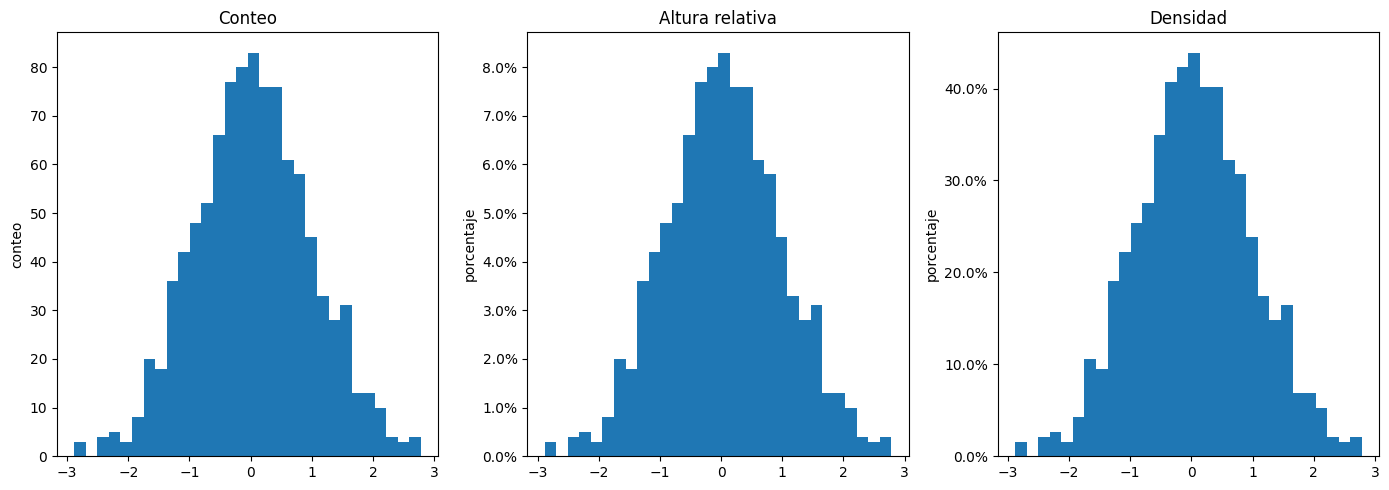

In [76]:
from matplotlib.ticker import PercentFormatter

# np.random.seed(0)
np.random.seed(4)
data = np.random.randn(1000)
n_bins = 30

# figura
plt.figure(figsize=(14,5))

# Subfigura 1
plt.subplot(1,3,1)
plt.hist(data, bins=n_bins)
plt.title('Conteo')
plt.ylabel('conteo')

# Subfigura 2
plt.subplot(1,3,2)
plt.hist(data, bins=n_bins, weights=np.ones(len(data)) / len(data))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Altura relativa')
plt.ylabel('porcentaje')

# Subfigura 3
plt.subplot(1,3,3)
plt.hist(data, bins=n_bins, density=True)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Densidad')
plt.ylabel('porcentaje')

# Pulir layout y mostrar
plt.tight_layout()
plt.show()

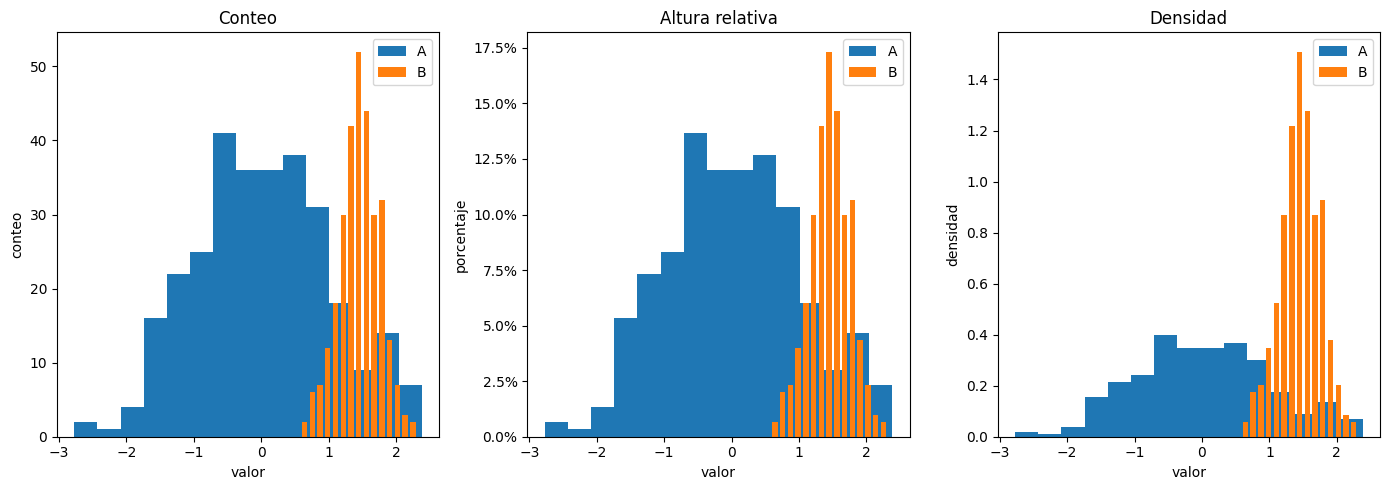

In [83]:

# figura
plt.figure(figsize=(14,5))

# Subfigura 1
plt.subplot(1,3,1)
plt.hist(datos1,15, label='A')
plt.hist(datos2,15, label='B',  rwidth=0.7)
plt.ylabel('conteo')
plt.xlabel('valor')
plt.title("Conteo")
plt.legend()

# Subfigura 2
plt.subplot(1,3,2)
plt.hist(datos1,15, weights=np.ones(len(datos1)) / len(datos1), label='A')
plt.hist(datos2,15, weights=np.ones(len(datos2)) / len(datos2), label='B',  rwidth=0.7)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylabel('porcentaje')
plt.xlabel('valor')
plt.title("Altura relativa")
plt.legend()

# Subfigura 3
plt.subplot(1,3,3)
plt.hist(datos1,15, density=True, label='A')
plt.hist(datos2,15, density=True, label='B',  rwidth=0.7)
plt.ylabel('densidad')
plt.xlabel('valor')
plt.title("Densidad")
plt.legend()

# Pulir layout y mostrar
plt.tight_layout()
plt.show()


---

## Variaciones de binsize / bin_number

Para un mismo conjunto de datos, la forma del histograma cambia con la cantidad de bines


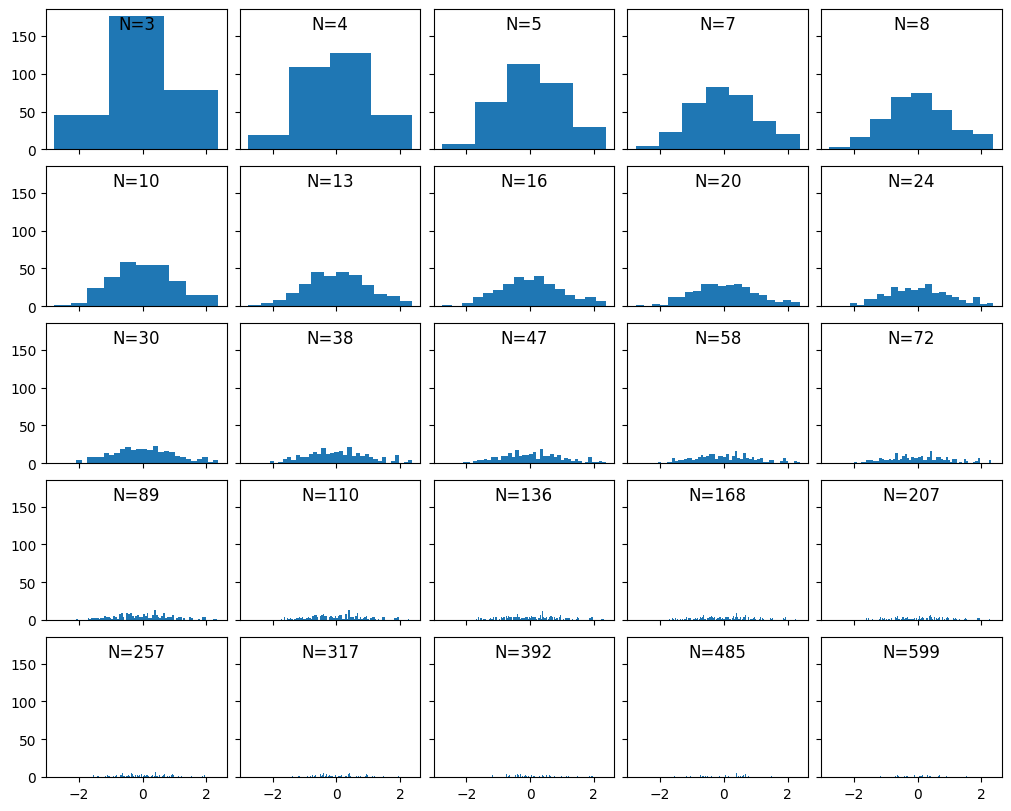

In [92]:

# Figura con ejes compartidos
fig,axx = plt.subplots(5,5,figsize=(10,8), sharex=True, sharey=True, constrained_layout=True)

# Fabrico lista de numeros de bin a graficar
L = len(datos1)*2
vector_N = np.unique(np.logspace(np.log10(3), np.log10(L),26).astype(int))

# Grafico por número
for N,ax in zip(vector_N,axx.flatten()):
    ax.set_title(f"N={N}", y=0.8)
    ax.hist(datos1,N)
    # ax.hist(datos1,N, density=True)
    # ax.set_ylim(0,1)

plt.show()

Hay distintas propuestas de óptimos según el área de aplicación y el tipo de dato / magnitud que se está analizando. Algunas reglas para $n$ datos:


* Regla de Sturge
  * Para datos de distribuciones simétricos o normales y continuos
$$
N_{bin}
=
\mathrm{round}\left(
1+3.322 \cdot \log(n)
\right)
$$

* Regla de Scott

$$
N_{bin}
=
\mathrm{round}\left(
1+3.49 \cdot \frac{\sigma }{ \sqrt[3]{n} }
\right)
$$


* Regla de Rice

$$
N_{bin}
=
\mathrm{round}\left(
  2\cdot \sqrt[3]{n}
\right)
$$


* Regla de Freedman-Diaconis
  * Se basa en el [intervalo interquartil IQR](https://es.wikipedia.org/wiki/Rango_intercuart%C3%ADlico)
$$
N_{bin}
=
\mathrm{round}\left(
  \frac{2\; \mathrm{IQR}}{ \sqrt[3]{n} }
\right)
$$

## Limites y bines compartidos

Otra forma de presentar histogramas comparados es sincronizar los limites de los bines. El numero de bines para una u otra distribucion de datos puede no ser optimo, pero la interpretación de cada columna es calara para ambos por igual.

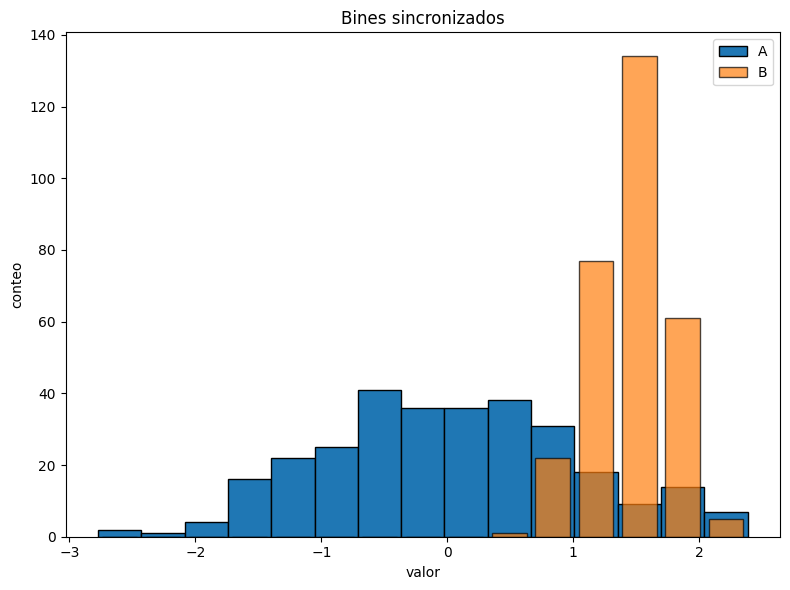

In [101]:
# Figura
plt.figure(figsize=(8,6))

# extraigo los parametros del primer plot
conteo_bines, limites_bines, obj_plot = plt.hist(datos1,15, label='A', edgecolor='black')

# uso los límites del primero en el segundo
plt.hist(datos2,limites_bines, label='B', edgecolor='black', rwidth=0.8, alpha=0.7)

plt.ylabel('conteo')
plt.xlabel('valor')
plt.title("Bines sincronizados")
plt.legend()

# Pulir layout y mostrar
plt.tight_layout()
plt.show()

## Efectos de muestreo

Las características de la muestra también afectan a la forma del histograma. Aspectos como la resolucion de los datos, cantidad de datos, o variaciones no previstas en el tiempo de adquisición de los datos.

Veamos algunos ejemplos

### Resolución de los datos

Si los datos están limitados por resolución pueden tener ciertos artificios al graficarlos





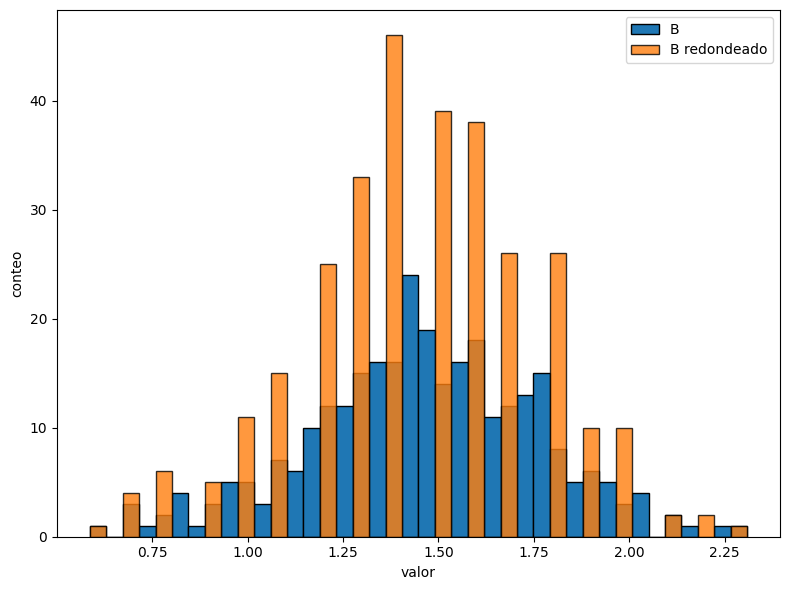

In [119]:
# Figura
plt.figure(figsize=(8,6))

_, limites, _ = plt.hist(datos2,40, label='B', edgecolor='black')
plt.hist( np.round(datos2,1),limites, label='B redondeado',
          edgecolor='black', alpha=0.8)

plt.ylabel('conteo')
plt.xlabel('valor')
plt.legend()
# Pulir layout y mostrar
plt.tight_layout()
plt.show()

### Muestra más representativa al haber más datos

- Dependencia temporal o paramétrica no prevista


In [145]:
from IPython.display import Image, display

# display(Image(filename=animation_filename))
display(Image(url="https://marceluda.github.io/python-para-fisicos/tuto/labo2/06_graficos_avanzandos/animation_beta_hist.gif", width=700))


#### Codigo animación

In [ ]:
!gdown 1l_yLOH8JoDVHPAREg4P635Ery_nOAmIk
animation_filename = "animation_beta.gif"


from scipy.stats import beta

# Parámetros de distribución
alpha = 2
beta_param = 5

# Genero datos aleatoreos
num_samples = 10000
samples = np.random.beta(alpha, beta_param, num_samples)

x = np.linspace(0, 1, 1000)
pdf = beta.pdf(x, alpha, beta_param)

# Plot the histogram of samples and overlay the PDF

def update(n):
    plt.cla()
    if n>10000:
        n=10000
    N=int(round(1+np.log(n)/np.log(2)*4))
    plt.hist(samples[:n], N ,density=True, alpha=0.7, color='skyblue', label='Histograma de Muestras')
    plt.plot(x, pdf, color='red', linewidth=2, label='Densidad de Probabilidad')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.title(f'N={n}', y=0.95)
    plt.legend()
    plt.ylim(0,4)


from matplotlib.animation import FuncAnimation, PillowWriter
import os

# Check if the GIF file already exists
if not os.path.exists(animation_filename):
    fig = plt.figure(figsize=(10, 6))

    frames = (3+np.linspace(0,1,300)**2*(11000-3)).astype(int)
    ani = FuncAnimation(fig, update, frames=frames)

    # Save as GIF using PillowWriter
    writer = PillowWriter(fps=15)
    ani.save(animation_filename, writer=writer)
    print(f"Animation saved as {animation_filename}")



### Dependencia temporal



Text(0, 0.5, 'valor')

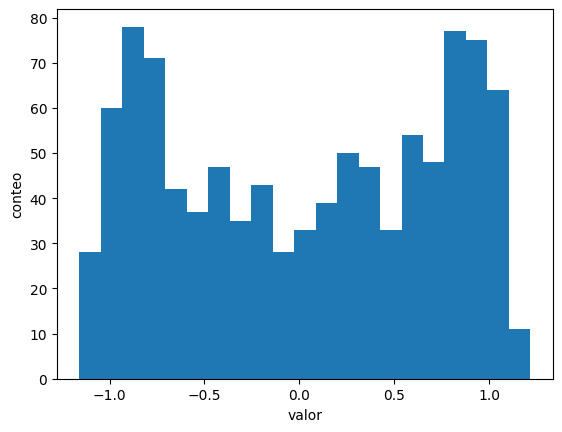

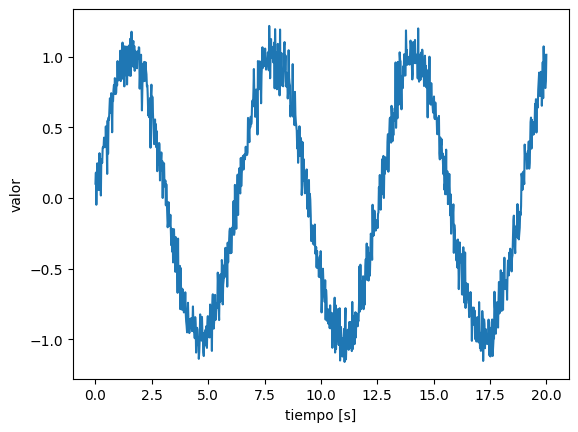

In [149]:

tiempo = np.linspace(0,20,1000)
datos_temporales = np.sin(tiempo) + np.random.normal(0,0.1,1000)


plt.figure()
plt.hist(datos_temporales,21)
plt.xlabel('valor')
plt.ylabel('conteo')

plt.figure()
plt.plot(tiempo,datos_temporales)
plt.xlabel('tiempo [s]')
plt.ylabel('valor')
